#Investigando o naufrágio do Titanic

Kaggle: https://www.kaggle.com/datasets/brendan45774/test-file

**Dicionário de Dados:**

* PassengerId: Número de identificação do passageiro
* Survived: Informa se o passageiro sobreviveu ao desastre
* * 0 = Não
* * 1 = Sim
* Pclass: Classe do bilhete
* * 1 = 1ª Classe
* * 2 = 2ª Classe
* * 3 = 3ª Classe
* Name: Nome do passageiro
* Sex: Sexo do passageiro
* Age: Idade do passageiro
* SibSp: Quantidade de cônjuges e irmãos a bordo
* Parch: Quantidade de pais e filhos a bordo
* Ticket: Número da passagem
* Fare: Preço da Passagem
* Cabin: Número da cabine do passageiro
* Embarked: Porto no qual o passageiro embarcou
* * C = Cherbourg
* * Q = Queenstown
* * S = Southampton

# Importar bibliotecas


In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   

# Leitura do dataset

In [114]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Q1. Quantas variáveis (colunas) e quantas entradas (linhas) possui o arquivo?

In [115]:
print(f"Número de Entradas: {df.shape[0]}")
print(f"Número de características: {df.shape[1]}")


Número de Entradas: 891
Número de características: 12


# Q2. Quais os tipos de cada variável?

In [116]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Q3. Qual a porcentagem de valores faltantes?  

In [117]:
# Calcular a porcentagem de valores faltantes para cada coluna
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Exibir as porcentagens
print("Porcentagem de valores faltantes por coluna:")
print(missing_percentage.sort_values(ascending=False))

Porcentagem de valores faltantes por coluna:
Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64


# Q4. Como é a distribuição estatística dos dados?

* Estatísticas resumidas
* Histograma

In [118]:
# Estatísticas resumidas
print("Estatísticas resumidas do dataset:")
print(df.describe())



Estatísticas resumidas do dataset:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


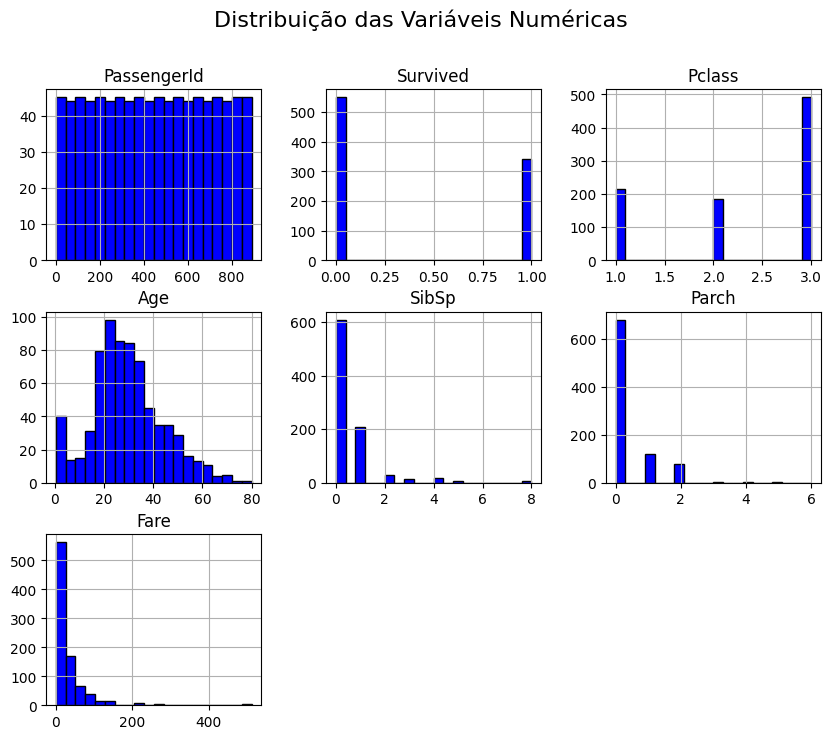

In [119]:
# Histograma para as variáveis numéricas
df.hist(bins=20, figsize=(10, 8), color='blue', edgecolor='black')
plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=16)
plt.show()


# Q4. Quais grupos de pessoas tinham mais chances de sobrevivência?

In [120]:
#Analisar a probabilidade
df[["Sex","Survived"]].groupby(["Sex"]).mean()

,Survived
Sex,
female,0.742038
male,0.188908


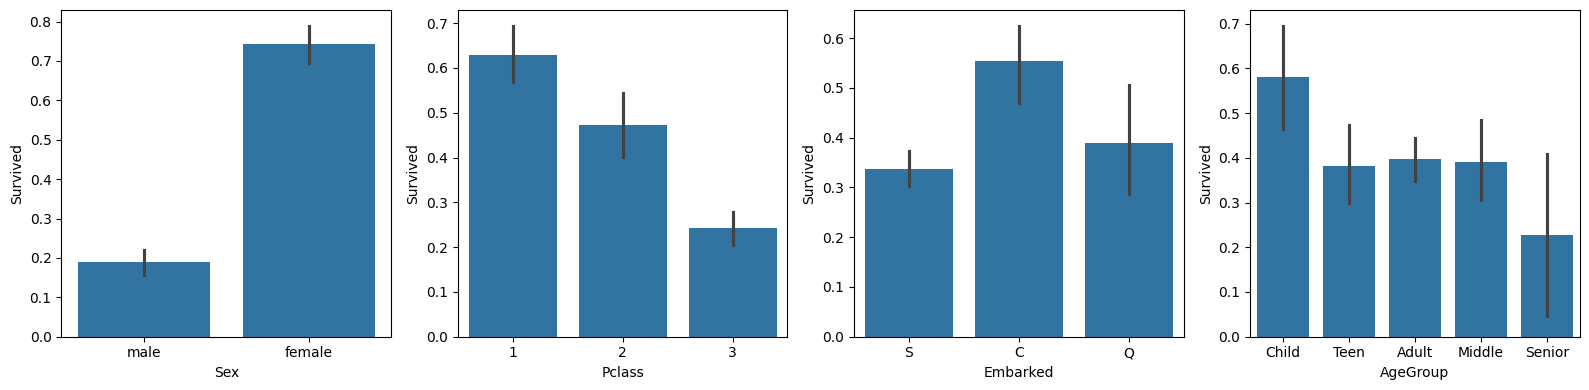

In [121]:
#Plotar
#Sex, Pclass, Embarked, e Ag


fig, (axis1, axis2, axis3, axis4) = plt.subplots(1, 4, figsize=(16, 4))

sns.barplot(x='Sex', y='Survived', data=df, ax=axis1)

sns.barplot(x='Pclass', y='Survived', data=df, ax=axis2)  # corrected column name

sns.barplot(x='Embarked', y='Survived', data=df, ax=axis3)

# For 'Age', better to bin into age groups first

df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 20, 40, 60, 80], labels=['Child', 'Teen', 'Adult', 'Middle', 'Senior'])

sns.barplot(x='AgeGroup', y='Survived', data=df, ax=axis4)

plt.tight_layout()

plt.show()

# Selecionar as features

* Desconsiderar as variáveis ['PassengerId', 'Name', 'Ticket', 'Cabin']

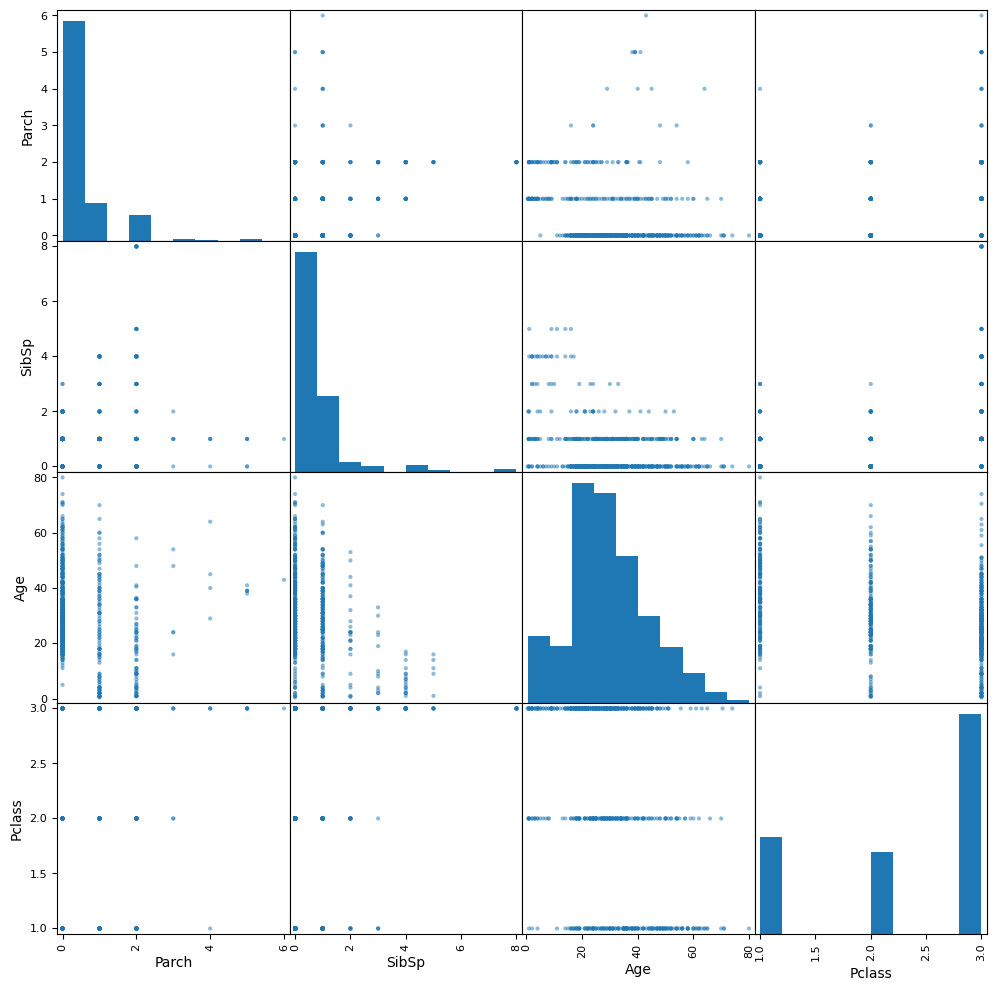

In [122]:
columns = ['Parch', 'SibSp', 'Age', 'Pclass']
pd.plotting.scatter_matrix(df[columns], figsize=(12, 12));


# Valores Faltantes

* Preencher esses valores arbitrariamente (média, mediana, valor mais frequente); e
* Excluir a linha inteira.

In [123]:
#Verificar valores faltantes
# Verificar valores faltantes
missing_values = df.isnull().sum()

# Exibir o total de valores faltantes por coluna
print("Valores faltantes por coluna:")
print(missing_values)

# Exibir as colunas com valores faltantes
columns_with_missing = missing_values[missing_values > 0]
print("\nColunas com valores faltantes:")
print(columns_with_missing)

Valores faltantes por coluna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
AgeGroup       177
dtype: int64

Colunas com valores faltantes:
Age         177
Cabin       687
Embarked      2
AgeGroup    177
dtype: int64


In [124]:
#Calcular a mediana
# Calcular a mediana da coluna 'Age'
age_median = df['Age'].median()

# Exibir a mediana calculada
print(f"A mediana da coluna 'Age' é: {age_median}")

A mediana da coluna 'Age' é: 28.0


In [125]:
# Calcular a mediana da coluna 'Age'
age_median = df['Age'].median()

# Preencher os valores nulos da coluna 'Age' com a mediana
df['Age'].fillna(age_median, inplace=True)

# Verificar se ainda existem valores nulos na coluna 'Age'
print(f"Valores nulos restantes na coluna 'Age': {df['Age'].isnull().sum()}")

Valores nulos restantes na coluna 'Age': 0


C:\Users\madso\AppData\Local\Temp\ipykernel_6528\3981386017.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(age_median, inplace=True)


In [126]:
#Verificar valores faltantes
# Verificar valores faltantes
missing_values = df.isnull().sum()

# Exibir o total de valores faltantes por coluna
print("Valores faltantes por coluna:")
print(missing_values)

# Exibir as colunas com valores faltantes
columns_with_missing = missing_values[missing_values > 0]
print("\nColunas com valores faltantes:")
print(columns_with_missing)

Valores faltantes por coluna:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
AgeGroup       177
dtype: int64

Colunas com valores faltantes:
Cabin       687
Embarked      2
AgeGroup    177
dtype: int64


In [127]:
# Calcular a principal ocorrência (valor mais frequente) na coluna 'Embarked'
most_frequent_embarked = df['Embarked'].mode()[0]

# Preencher os valores nulos da coluna 'Embarked' com a principal ocorrência
df['Embarked'].fillna(most_frequent_embarked, inplace=True)

# Verificar se ainda existem valores nulos na coluna 'Embarked'
print(f"Valores nulos restantes na coluna 'Embarked': {df['Embarked'].isnull().sum()}")

Valores nulos restantes na coluna 'Embarked': 0


C:\Users\madso\AppData\Local\Temp\ipykernel_6528\250355954.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(most_frequent_embarked, inplace=True)


# Preparar as variáveis para o modelo

* Sex para {'male': 0, 'female': 1}
* dummy para 'Embarked'


In [128]:
# Converter a coluna 'Sex' para valores numéricos
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Verificar a conversão
print(df['Sex'].head())


0    0
1    1
2    1
3    1
4    0
Name: Sex, dtype: int64


In [129]:
# Criar dummies para a coluna 'Embarked'    
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
# Verificar as primeiras linhas do DataFrame após a conversão                   
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,AgeGroup,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,Adult,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,Adult,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,Adult,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,Adult,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,Adult,False,True
